# Using the Skincare Products▴EDA & Sentiment Analysis dataset for the assessment

# Project steps

Step-1: Import Libraries

Step-2: Load all the reviews data set

step-3: merge the datasets into a dataframe

step-4: Explore the dataset

step-5: Handle the missing values

step-6: clean the reviews datasets

step-7: Rule based filtering

step-8: complaint keyword analysis

step-9: visualising the data

step-10: select top 3 critical values

step-11: Generate AI emails using google gemini API

step-12: creating the readme file

In [ ]:
# Step-1: Import the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google import genai # will use this to generate ai response emails
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#step-2: load all the customer reviews datasets
review1=pd.read_csv("reviews_0-250_masked.csv")
review2=pd.read_csv("reviews_250-500_masked.csv")
review3=pd.read_csv("reviews_500-750_masked.csv")
review4=pd.read_csv("reviews_750-1250_masked.csv")
review5=pd.read_csv("reviews_1250-end_masked.csv")

In [ ]:
#step-3: Merge all the reviews
reviews=pd.concat([review1,review2,review3,review4,review5],
                   ignore_index=True) #used to create new row numbers to avoid the confusion

In [ ]:
#step-4: Explore the dataset
reviews.head() #displays the first 5 rows of the dataframe

In [ ]:
reviews.shape #displays no of rows and columns exist in the given data

In [ ]:
reviews.columns #displays the list of all the column names

In [ ]:
reviews.info() #displays summary of datatypes, structure layout and memory usage

In [ ]:
reviews.describe() #gives summary statistic of numeric columns

In [ ]:
reviews.sample(5)

In [ ]:
# step-5: Handle the missing values (Data cleaning)
reviews.isnull() #used to find the null values

In [ ]:
reviews.isnull().sum() # used to count the no of null values in the series of the data

In [ ]:
missing_values=reviews.isnull().sum()
missing_values=missing_values[missing_values>0]
print(missing_values)
# here we are filtering the sum of data with null values

In [ ]:
reviews=reviews.dropna(subset=["review_text"]) #creating a subset only remove rows where the review_text column is missing.
reviews["review_text"].isnull().sum()


In [ ]:
reviews["review_text"].isnull().sum()

In [ ]:
#check for duplicate rows
reviews.duplicated().sum()
#remove duplicatesif existed
reviews = reviews.drop_duplicates()


In [ ]:
#check final dataset size
# Verify duplicates are removed
print("Duplicate rows after removal:", reviews.duplicated().sum())

# Check final dataset size
print(reviews.shape)

In [ ]:
#Step-6: Step 6 – Clean the Reviews dataset

# Convert to lowercase
reviews["review_text"] = reviews["review_text"].str.lower()

# Remove punctuation and numbers
reviews["review_text"] = reviews["review_text"].str.replace(
    r"[^a-zA-Z\s]",
    "",
    regex=True
)

# Remove extra spaces
reviews["review_text"] = reviews["review_text"].str.replace(
    r"\s+",
    " ",
    regex=True
)

# Remove leading/trailing spaces
reviews["review_text"] = reviews["review_text"].str.strip()

^ - NOT
a-z - Lower case
A_Z - Upper Case
\s - spaces


In [ ]:
# step-7: Rule based filtering

#creating a dataframe for critical reviews
critical_reviews=reviews[reviews["rating"]<=2]

#reset the index
critical_reviews=critical_reviews.reset_index(drop=True)


In [ ]:
# creating dataframe for non critical reviews
non_critical_reviews = reviews[reviews["rating"] > 2]

# Reset the index
non_critical_reviews = non_critical_reviews.reset_index(drop=True)

In [ ]:
critical_reviews.head()

In [ ]:
non_critical_reviews.head()

In [ ]:
# creating the count of the reviews
print("total_reviews:",len(reviews))
print("Critical_reviews:",len(critical_reviews))
print("Non_critical_reviews:",len(non_critical_reviews))

In [ ]:
# comparing the critical and non critical reviews
summary=pd.DataFrame({"Category":["Critical","Non-Critical"],
                                  "Count":[len(critical_reviews),
                                           len(non_critical_reviews)
                                           ]
})

In [ ]:
# calculating the percentage
summary["percentage"]=(summary["Count"]/len(reviews))*100
summary["percentage"] = summary["percentage"].round(2)

In [ ]:
#comparing the average of the ratings
summary["Average Rating"] = [critical_reviews["rating"].mean(),non_critical_reviews["rating"].mean()]
summary["Average Rating"] = summary["Average Rating"].round(2)

In [ ]:
print(summary)

In [ ]:
#step-8:complaint keyword analysis

#finding the top complaint keywords from critical_reviews dataframe

review_text = critical_reviews["review_text"]
all_reviews = " ".join(review_text)

In [ ]:
#splitting all the reviews into individual words
words = all_reviews.split()

In [ ]:
# filtering the common words and symbols
stop_words = [
    "the","and","is","a","an","to","of","for","in","on","at","with",
    "this","that","it","its","i","my","me","we","our","you","your",
    "after","before","when","where","then","than",
    "only","really","also","still","just","even",
    "got","get","use","used","using",
    "reviews","review","product","products",
    "one","two","first","last","time",
    "nice","good","better","give","stars",
    "went","made","make","like","love","want",
    "think","well","much","more","now","around",
    "all","out","dont","didnt"
]

filtered_words = []

for word in words:
    if word not in stop_words and word not in ["|","","-",".",",","(",")"]:
        filtered_words.append(word)



In [ ]:
# counting each word by creating an empty dictionary
word_frequency = {}

for word in filtered_words:
    if word in word_frequency:
        word_frequency[word] += 1
    else:
        word_frequency[word] = 1

In [ ]:
# converting the dictionary into a data frame
df_freq = pd.DataFrame(
    word_frequency.items(),
    columns=["Keyword", "Frequency"]
)

df_freq = df_freq.sort_values(
    by="Frequency",
    ascending=False
)

df_freq = df_freq.reset_index(drop=True)

Above we can see that these are not complaint keywords they are comon english keywords called stop words

# Top 10 complaint keywords

skin

dry

face

out

its

all

did'nt

cleanser

mask

don't

In [ ]:
# step-9: Visualizing the Data

#comparing the critical vs non critical reviews using the bar chart
plt.figure(figsize=(6,4))
plt.bar(summary["Category"],summary["Count"])
plt.title("Critical vs Non-Critical Reviews")
plt.xlabel("Review Category")
plt.ylabel("Number of reviews")

plt.show()

# Bar chart representing the critical vs Non-Critical reviews
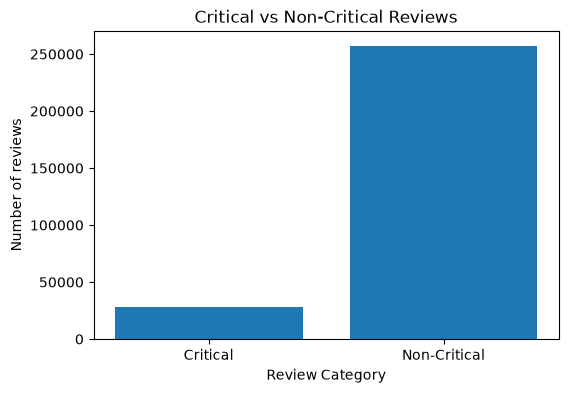

In [ ]:
# percentage of critical and non critical reviews
plt.figure(figsize=(6,6))

plt.pie(
    summary["percentage"],
    labels=summary["Category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Critical and Non-Critical Reviews")

plt.show()

# pie chart representing the Critical and Non Critical reviews percentage
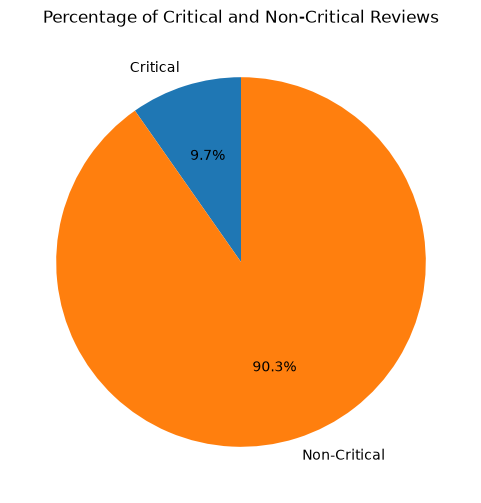

In [ ]:
top_keywords = df_freq.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_keywords["Keyword"],
    top_keywords["Frequency"]
)

plt.title("Top 10 Complaint Keywords")
plt.xlabel("Keywords")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

# Bar Graph showing Top 10 complaint keywords
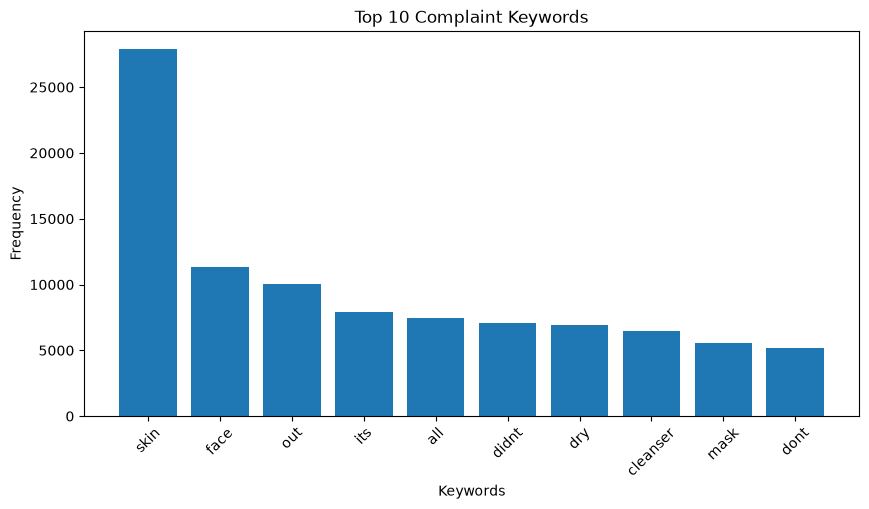

In [ ]:
print(filtered_words[:50])

In [ ]:
# Step-10: select top 3 critical values

top_3_reviews=critical_reviews.head(3)
print(top_3_reviews[["product_name","rating","review_title","review_text"]])
top_3_reviews=top_3_reviews.reset_index(drop=True)

In [ ]:
from google import genai
client = genai.Client(
    api_key="YOUR API KEY"
)


In [ ]:
generated_emails = []

In [ ]:
for index, row in top_3_reviews.iterrows():

    prompt = f"""
You are a professional customer support executive.

Write a polite, empathetic, and professional email responding to the customer's review.

Product Name:
{row['product_name']}

Rating:
{row['rating']}

Review Title:
{row['review_title']}

Review:
{row['review_text']}

The email should:
1. Thank the customer for sharing their feedback.
2. Apologize for their negative experience.
3. Acknowledge the specific issue mentioned.
4. Assure them that their feedback will be shared with the product team.
5. Offer further assistance if needed.
6. End the email professionally.

Generate only the email.
"""

    response = client.models.generate_content(
        model="gemini-2.0-flash",
        contents=prompt
    )

    generated_emails.append(response.text)

In [ ]:
top_3_reviews["generated_email"] = generated_emails 

In [ ]:
print(
    top_3_reviews[
        [
            "product_name",
            "review_title",
            "generated_email"
        ]
    ]
)

# Generated email responses
Unnamed: 0.1,Unnamed: 0,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd,generated_email
1,1,1,0.0,,0,0,0,2023-03-21,i bought this lip mask after reading the reviews and the hype unfortunately it did not meet my expectations as vaseline petroleum jelly works way better for me,Disappointed,,,,,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0,"Subject: We're sorry to hear about your experience with our Lip Sleeping Mask

Dear [Customer Name],

Thank you for taking the time to share your feedback regarding your recent purchase of our **Lip Sleeping Mask Intense Hydration with Vitamin C**. We truly appreciate you giving our product a try.

I am so sorry to hear that the lip mask did not meet your expectations, especially after all the hype and positive reviews you had read. We completely understand how disappointing it is when a product doesn't deliver the results you were hoping for, particularly when a simple staple like petroleum jelly works better for your needs. 

Since skin and lip chemistry can vary greatly from person to person, we know that not every product will be a perfect fit for everyone. That said, your satisfaction is extremely important to us, and we want to make things right. 

I would be happy to process a full refund for your purchase, or if you prefer, help you find an alternative product from our line that might suit you better. Please reply to this email with your order number or purchase details, and I will take care of this for you right away.

Thank you again for your honest feedback—it helps us continuously improve. 

Warm regards,

[Your Name]  
Customer Support Representative  
[Company Name]"
6,6,2,0.0,0.25,8,6,2,2023-03-19,ill give this stars for nice packaging and lovely scent upon initial application it feels very nice but as i continued to use it i noticed i was getting more and more blackheadsclogged pores and pimples around my lips i thought it was my aquaphor but its this it also makes my lips even more dry than they initially were disappointing around my,Dried my lips out and clogged my pores,light,blue,combination,brown,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0,"Subject: We're sorry to hear about your experience with our Lip Sleeping Mask

Dear [Customer Name],

Thank you for taking the time to leave us your feedback regarding your recent purchase of our Lip Sleeping Mask Intense Hydration with Vitamin C. We truly appreciate you mentioning that you enjoyed the packaging and the lovely scent.

However, I am sincerely sorry to hear about your experience with the product. We always aim to provide deeply hydrating skincare solutions, so it is very disappointing to learn that the mask caused increased dryness as well as clogged pores and breakouts around your lips. We understand how frustrating this must be, especially when you were expecting intense hydration.

Because everyone's skin is unique, certain ingredients can sometimes cause unexpected reactions. Your satisfaction and well-being are our top priorities, and we would love the opportunity to make this right for you. 

Please reply directly to this email with your order number or purchase details, and I will be more than happy to issue a full refund or assist you with an exchange for a product better suited to your skin.

Thank you again for bringing this to our attention, as your feedback helps us continuously improve. We look forward to resolving this for you soon.

Warm regards,

[Your Name]  
Customer Care Team  
[Company/Brand Name]"
13,13,1,0.0,0.4444440007209778,9,5,4,2023-03-17,honestly i was so excited when i got this in the mail but unfortunately it is not worth the hype i have boughten two of these full size and i went through them so quickly the ingredients are not very clean and this product made my lips so dry i wanted to like this product so bad as its so cute and smells nice but unfortunately it is a hard pass for me i will be sticking to my vaseline and aquaphor for now,I WISHED I LOVED THIS (not clean ingredients),,brown,dry,,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0,"Subject: We’re so sorry to hear about your experience – Lip Sleeping Mask

Dear [Customer Name],

Thank you for taking the time to share your honest feedback regarding our Lip Sleeping Mask Intense Hydration with Vitamin C. 

I am truly sorry to hear that your experience fell short of your expectations. We know how exciting it is to try a new product—especially one you were looking forward to—so it is disappointing to learn that it left your lips feeling dry rather than hydrated, and that you went through the jars so quickly. 

We also deeply appreciate your feedback regarding our ingredients. We strive to create products that our customers can use with confidence, and hearing your thoughts on clean formulations is extremely valuable to our team as we continuously work to improve. 

Since you purchased two full-sized jars and were not satisfied with the results, we would love the opportunity to make things right. Please reply to this email with your order number or purchase details, and our team will be happy to assist you with a refund or help process a return. If you'd like, we can also recommend alternative products from our line that better align with your preference for clean ingredients and intense moisture.

Thank you again for reaching out and helping us do better. We wish you the very best and hope to have the chance to restore your confidence in us in the future.

Warm regards,

[Your Name]  
Customer Care Team  
[Company Name]"